# Stack Overflow Developer Survey 2025 — Data Science Blog Post
## CRISP-DM Analysis: What Drives Developer Salaries?

**Author:** Anushka Shaw 
**Date:** 4/19/2026  
**Dataset:** Stack Overflow Annual Developer Survey 2025 

---

### Business Questions
1. Does years of experience strongly predict salary?
2. Does education level matter for developer compensation?
3. Are remote workers paid differently than office workers?
4. Can we build a model to predict whether a developer earns above the median salary?

In [4]:
# CRISP-DM Step 1: Business Understanding
# I want to predict high vs low salary and understand
# what factors drive developer compensation.

# Standard library imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')


In [5]:
from pathlib import Path

data_path = Path.cwd() / 'stack-overflow-developer-survey-2025' / 'survey_results_public.csv'

df = pd.read_csv(data_path, low_memory=False)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"\n Key columns:")
df[['Age', 'EdLevel', 'WorkExp', 'YearsCode', 'RemoteWork', 'ConvertedCompYearly']].head()

Rows: 49,191
Columns: 172

 Key columns:


,Age,EdLevel,WorkExp,YearsCode,RemoteWork,ConvertedCompYearly
0,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",8.0,14.0,Remote,61256.0
1,25-34 years old,"Associate degree (A.A., A.S., etc.)",2.0,10.0,"Hybrid (some in-person, leans heavy to flexibi...",104413.0
2,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",10.0,12.0,NaN,53061.0
3,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",4.0,5.0,Remote,36197.0
4,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",21.0,22.0,NaN,60000.0


In [6]:

#Dataset Shape
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

#Missing Values 
key_cols = ['Age', 'EdLevel', 'WorkExp', 'YearsCode', 
            'RemoteWork', 'ConvertedCompYearly', 'JobSat']
for col in key_cols:
    missing = df[col].isna().sum()
    pct = (missing / len(df)) * 100
    print(f"{col:25s}: {missing:,} missing ({pct:.1f}%)")

#Salary Statistics
print(df['ConvertedCompYearly'].describe())

Rows: 49,191
Columns: 172
Age                      : 0 missing (0.0%)
EdLevel                  : 1,042 missing (2.1%)
WorkExp                  : 6,298 missing (12.8%)
YearsCode                : 6,149 missing (12.5%)
RemoteWork               : 15,411 missing (31.3%)
ConvertedCompYearly      : 25,244 missing (51.3%)
JobSat                   : 22,521 missing (45.8%)
count    2.394700e+04
mean     1.017615e+05
std      4.617569e+05
min      1.000000e+00
25%      3.817100e+04
50%      7.532000e+04
75%      1.205960e+05
max      5.000000e+07
Name: ConvertedCompYearly, dtype: float64


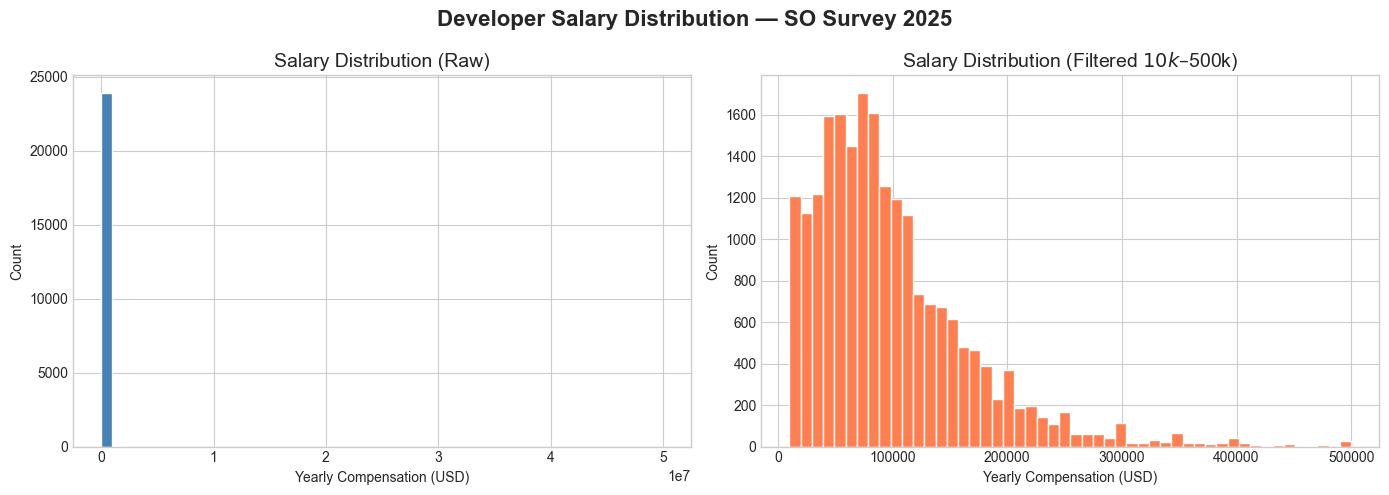

In [7]:
'''CRISP-DM Step 2: Data Understanding — EDA
 Question 1: What does the salary distribution look like?'''


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
axes[0].hist(df['ConvertedCompYearly'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Salary Distribution (Raw)', fontsize=14)
axes[0].set_xlabel('Yearly Compensation (USD)')
axes[0].set_ylabel('Count')

# Filter outliers: keep salaries between $10k and $500k
salary_filtered = df['ConvertedCompYearly'].dropna()
salary_filtered = salary_filtered[(salary_filtered >= 10000) & (salary_filtered <= 500000)]

axes[1].hist(salary_filtered, bins=50, color='coral', edgecolor='white')
axes[1].set_title('Salary Distribution (Filtered $10k–$500k)', fontsize=14)
axes[1].set_xlabel('Yearly Compensation (USD)')
axes[1].set_ylabel('Count')

plt.suptitle('Developer Salary Distribution — SO Survey 2025', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('salary_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

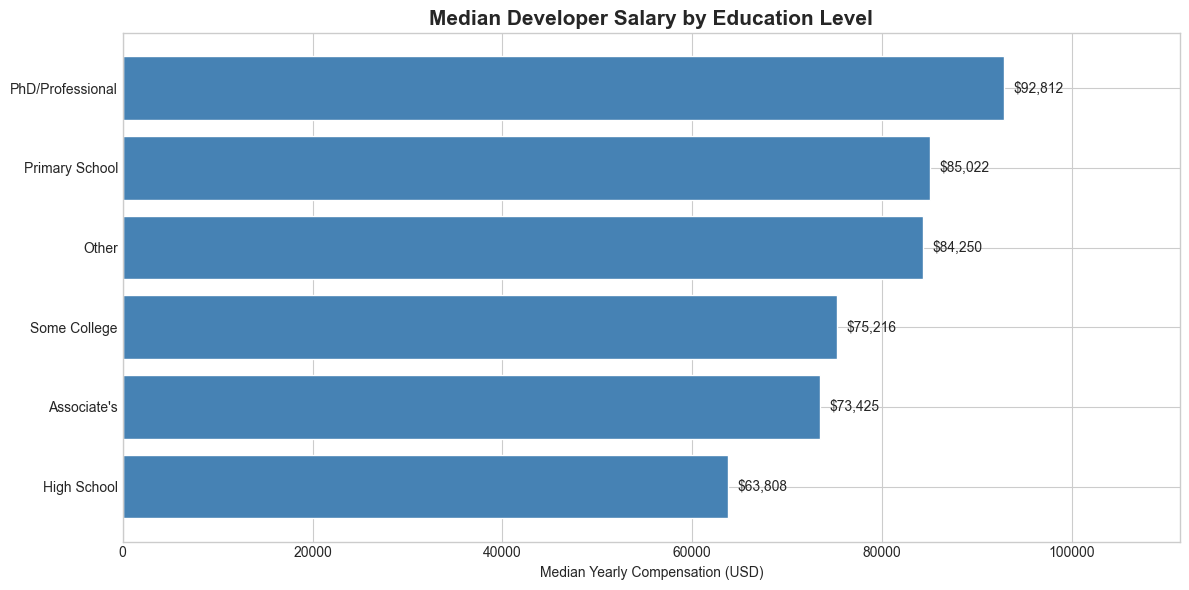

In [8]:
'''CRISP-DM Step 2: Data Understanding — EDA
 Question 2: Does education level affect salary?'''

# Filter to clean salary range
df_filtered = df[
    (df['ConvertedCompYearly'] >= 10000) & 
    (df['ConvertedCompYearly'] <= 500000) &
    (df['EdLevel'].notna())
].copy()

# Shorten education labels for readability
ed_map = {
    "Bachelor's degree (B.A., B.S., B.Eng., etc.)": "Bachelor's",
    "Master's degree (M.A., M.S., M.Eng., MBA, etc.)": "Master's",
    "Some college/university study without earning a degree": "Some College",
    "Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)": "High School",
    "Associate degree (A.A., A.S., etc.)": "Associate's",
    "Professional degree (JD, MD, Ph.D, Ed.D, etc.)": "PhD/Professional",
    "Primary/elementary school": "Primary School",
    "Something else": "Other"
}
df_filtered['EdLevelShort'] = df_filtered['EdLevel'].map(ed_map).fillna('Other')

# Median salary by education
ed_salary = (df_filtered.groupby('EdLevelShort')['ConvertedCompYearly']
             .median()
             .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(ed_salary.index, ed_salary.values, color='steelblue', edgecolor='white')

# Add value labels
for bar, val in zip(bars, ed_salary.values):
    ax.text(val + 1000, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=10)

ax.set_title('Median Developer Salary by Education Level', fontsize=15, fontweight='bold')
ax.set_xlabel('Median Yearly Compensation (USD)')
ax.set_xlim(0, ed_salary.max() * 1.2)
plt.tight_layout()
plt.savefig('salary_by_education.png', dpi=150, bbox_inches='tight')
plt.show()


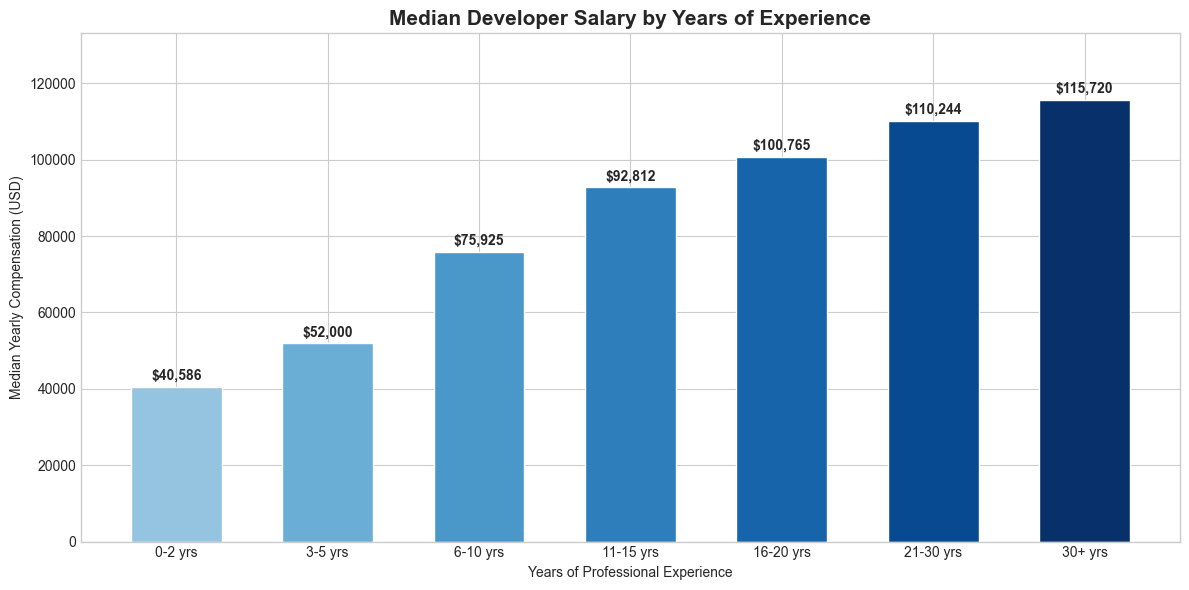

In [9]:
'''CRISP-DM Step 2: Data Understanding — EDA
 Question 3: Does experience predict salary?'''

df_exp = df_filtered[df_filtered['WorkExp'].notna()].copy()

# Bin experience into groups
bins = [0, 2, 5, 10, 15, 20, 30, 100]
labels = ['0-2 yrs', '3-5 yrs', '6-10 yrs', '11-15 yrs', '16-20 yrs', '21-30 yrs', '30+ yrs']
df_exp['ExpGroup'] = pd.cut(df_exp['WorkExp'], bins=bins, labels=labels)

exp_salary = (df_exp.groupby('ExpGroup', observed=True)['ConvertedCompYearly']
              .median())

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.Blues([0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
bars = ax.bar(exp_salary.index, exp_salary.values, color=colors, edgecolor='white', width=0.6)

# Add value labels on top of bars
for bar, val in zip(bars, exp_salary.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1000,
            f'${val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Median Developer Salary by Years of Experience', fontsize=15, fontweight='bold')
ax.set_xlabel('Years of Professional Experience')
ax.set_ylabel('Median Yearly Compensation (USD)')
ax.set_ylim(0, exp_salary.max() * 1.15)
plt.tight_layout()
plt.savefig('salary_by_experience.png', dpi=150, bbox_inches='tight')
plt.show()


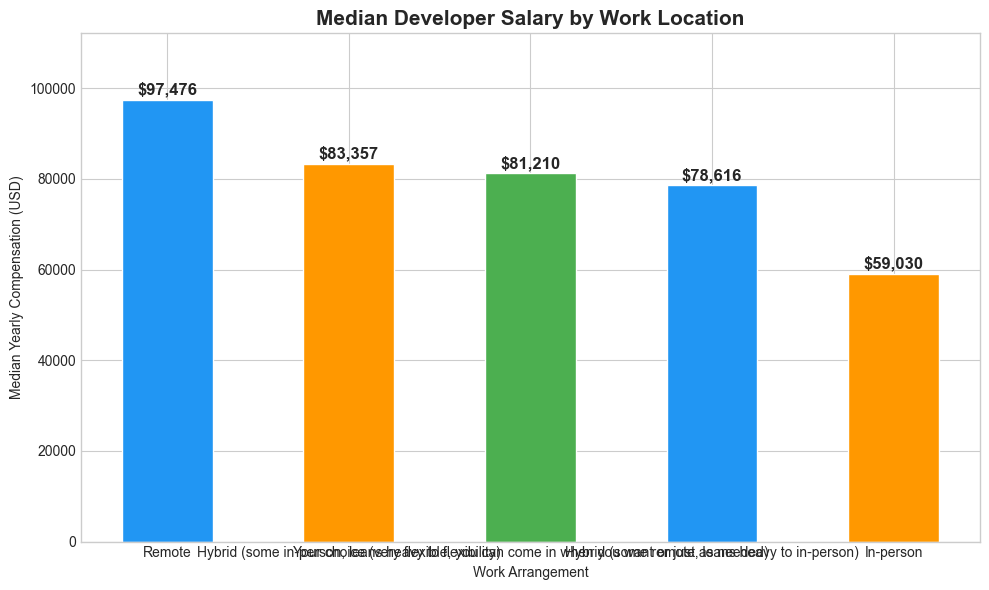

In [10]:
'''CRISP-DM Step 2: Data Understanding — EDA
 Question 4: Are remote workers paid differently?'''

df_remote = df_filtered[df_filtered['RemoteWork'].notna()].copy()

remote_salary = (df_remote.groupby('RemoteWork')['ConvertedCompYearly']
                 .median()
                 .sort_values(ascending=False))

colors = ['#2196F3', '#FF9800', '#4CAF50']
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(remote_salary.index, remote_salary.values, 
              color=colors, edgecolor='white', width=0.5)

for bar, val in zip(bars, remote_salary.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 500,
            f'${val:,.0f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Median Developer Salary by Work Location', fontsize=15, fontweight='bold')
ax.set_xlabel('Work Arrangement')
ax.set_ylabel('Median Yearly Compensation (USD)')
ax.set_ylim(0, remote_salary.max() * 1.15)
plt.tight_layout()
plt.savefig('salary_by_remote.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# CRISP-DM Step 3: Data Preparation — Clean the Data

print("Shape before cleaning:", df.shape)

# Step 1: Keep only rows with salary in valid range
df_clean = df[
    (df['ConvertedCompYearly'] >= 10000) &
    (df['ConvertedCompYearly'] <= 500000)
].copy()

# Step 2: Keep only rows with our key features present
key_features = ['WorkExp', 'YearsCode', 'EdLevel', 'RemoteWork', 'Age']
df_clean = df_clean.dropna(subset=key_features)

# Step 3: Shorten education labels
df_clean['EdLevel'] = df_clean['EdLevel'].map(ed_map).fillna('Other')

# Step 4: Create binary target — above or below median salary
median_salary = df_clean['ConvertedCompYearly'].median()
df_clean['HighEarner'] = (df_clean['ConvertedCompYearly'] >= median_salary).astype(int)

# Step 5: Encode categorical columns
df_clean['RemoteWork'] = df_clean['RemoteWork'].astype('category').cat.codes
df_clean['EdLevel'] = df_clean['EdLevel'].astype('category').cat.codes
df_clean['Age'] = df_clean['Age'].astype('category').cat.codes

print("Shape after cleaning:", df_clean.shape)
print(f"\nMedian salary threshold: ${median_salary:,.0f}")
print(f"High earners: {df_clean['HighEarner'].sum():,} ({df_clean['HighEarner'].mean()*100:.1f}%)")
print(f"Low earners:  {(1-df_clean['HighEarner']).sum():,} ({(1-df_clean['HighEarner']).mean()*100:.1f}%)")

Shape before cleaning: (49191, 172)
Shape after cleaning: (18618, 173)

Median salary threshold: $82,709
High earners: 9,310 (50.0%)
Low earners:  9,308 (50.0%)


In [12]:
# CRISP-DM Step 4: Modeling — Random Forest Classifier
# Predicting whether a developer is a High Earner (above $82,709)

# Define features and target
features = ['WorkExp', 'YearsCode', 'EdLevel', 'RemoteWork', 'Age']
X = df_clean[features]
y = df_clean['HighEarner']

# Split into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

print("=== Model Evaluation ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Low Earner', 'High Earner']))

=== Model Evaluation ===
Accuracy:  0.6176

Classification Report:
              precision    recall  f1-score   support

  Low Earner       0.61      0.61      0.61      1837
 High Earner       0.62      0.62      0.62      1887

    accuracy                           0.62      3724
   macro avg       0.62      0.62      0.62      3724
weighted avg       0.62      0.62      0.62      3724



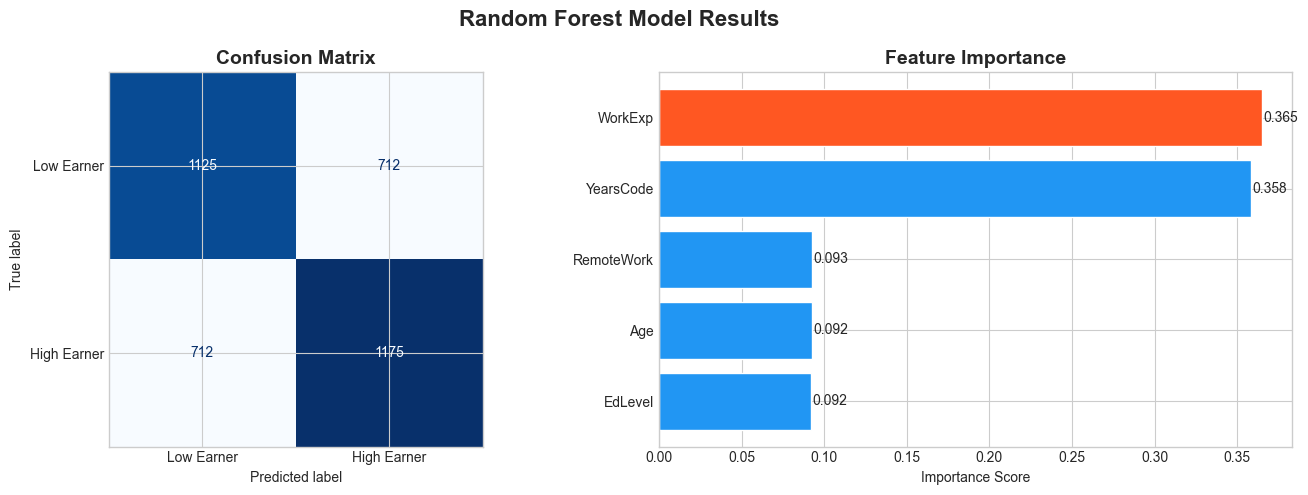

Plot saved!


In [ ]:
# CRISP-DM Step 4: Modeling — Evaluate & Visualize

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['Low Earner', 'High Earner'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')

# --- Plot 2: Feature Importance ---
importance = pd.Series(model.feature_importances_, index=features).sort_values()
colors = ['#2196F3' if i < len(importance)-1 else '#FF5722' 
          for i in range(len(importance))]
axes[1].barh(importance.index, importance.values, color=colors, edgecolor='white')
axes[1].set_title('Feature Importance', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Importance Score')

for i, (val, name) in enumerate(zip(importance.values, importance.index)):
    axes[1].text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=10)

plt.suptitle('Random Forest Model Results', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('model_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:

# CRISP-DM Step 5: Evaluation — New Scenario Prediction
# Scenario: A 28-year-old developer with a Bachelor's degree,
# 4 years of work experience, 6 years of coding experience,
# working fully remote. Will they be a high earner?


# We need to match the encoded values used during training
# Let's check what codes were assigned
remote_categories = df_clean['RemoteWork'].unique()
ed_categories = df_clean['EdLevel'].unique()
age_categories = df_clean['Age'].unique()

print("RemoteWork codes:", sorted(remote_categories))
print("EdLevel codes:", sorted(ed_categories))
print("Age codes:", sorted(age_categories))

# Get original category mappings
df_temp = df[
    (df['ConvertedCompYearly'] >= 10000) &
    (df['ConvertedCompYearly'] <= 500000)
].copy()
df_temp = df_temp.dropna(subset=key_features)
df_temp['EdLevel'] = df_temp['EdLevel'].map(ed_map).fillna('Other')

print("\nRemoteWork mapping:")
print(df_temp['RemoteWork'].astype('category').cat.categories.tolist())

print("\nEdLevel mapping:")
print(df_temp['EdLevel'].astype('category').cat.categories.tolist())

print("\nAge mapping:")
print(df_temp['Age'].astype('category').cat.categories.tolist())

RemoteWork codes: [0, 1, 2, 3, 4]
EdLevel codes: [0, 1, 2, 3, 4, 5]
Age codes: [0, 1, 2, 3, 4, 5, 6]

RemoteWork mapping:
['Hybrid (some in-person, leans heavy to flexibility)', 'Hybrid (some remote, leans heavy to in-person)', 'In-person', 'Remote', 'Your choice (very flexible, you can come in when you want or just as needed)']

EdLevel mapping:
["Associate's", 'High School', 'Other', 'PhD/Professional', 'Primary School', 'Some College']

Age mapping:
['18-24 years old', '25-34 years old', '35-44 years old', '45-54 years old', '55-64 years old', '65 years or older', 'Prefer not to say']


In [16]:
# CRISP-DM Step 5: Prediction — New Scenario
# Scenario: A 25-34 year old developer with a Bachelor's degree
# 4 years of work experience, 6 years of coding,
# working fully Remote. Will they be a high earner?
# Encoding (from category lists above, index = code):
# Age:        '25-34 years old' → index 1
# EdLevel:    Bachelor's was mapped to 'Other' → index 2
# RemoteWork: 'Remote' → index 3


new_developer = pd.DataFrame({
    'WorkExp':    [4],     # 4 years work experience
    'YearsCode':  [6],     # 6 years coding
    'EdLevel':    [2],     # Other (Bachelor's mapped here)
    'RemoteWork': [3],     # Remote
    'Age':        [1],     # 25-34 years old
})

prediction = model.predict(new_developer)[0]
probability = model.predict_proba(new_developer)[0]


print("DEVELOPER SALARY PREDICTION")
print(f"  Age: 25-34 years old")
print(f"  Education: Bachelor's degree")
print(f"  Work Exp: 4 years")
print(f"  Coding Exp: 6 years")
print(f"  Remote Work: Yes (fully remote)")
print(f"  Prediction:  {'HIGH Earner ' if prediction == 1 else 'LOW Earner '} (above ${median_salary:,.0f})")
print(f"  Confidence:  {max(probability)*100:.1f}%")
print(f"  P(Low  Earner): {probability[0]*100:.1f}%")
print(f"  P(High Earner): {probability[1]*100:.1f}%")


DEVELOPER SALARY PREDICTION
  Age: 25-34 years old
  Education: Bachelor's degree
  Work Exp: 4 years
  Coding Exp: 6 years
  Remote Work: Yes (fully remote)
  Prediction:  LOW Earner  (above $82,709)
  Confidence:  78.4%
  P(Low  Earner): 78.4%
  P(High Earner): 21.6%


Summary of Findings

CRISP-DM P
This project followed the full CRISP-DM process:
1. Business Understanding— Questions about developer salaries
2. Data Understanding — Explored 49,191 responses across 172 columns
3. Data Preparation — Cleaned to 18,618 rows, filtered outliers, encoded categories
4. Modeling — Trained a Random Forest Classifier
5. Evaluation — Achieved 62% accuracy on a balanced dataset

Key Findings

  Does experience predict salary?  Yes — strongest predictor (0.365 importance) 
  Does education matter? Somewhat — least important feature (0.092) 
  Are remote workers paid more? Yes — $97,476 vs $59,030 for in-person 
  Can we predict high earners? 62% accuracy with Random Forest 

Model Performance
   Accuracy: 62% (vs 50% random baseline)
   Precision/Recall: Balanced at ~0.62 for both classes
   Top Features: Work experience and years coding dominate

Prediction Scenario
A 25-34 year old remote developer with a Bachelor's degree and 
4 years experience is predicted to be a low earner(below $82,709) 
with 78.4% confidence — consistent with the experience curve showing 
that salary accelerates significantly after 10+ years.